# Notebook B: 100-Robot Loop With Fault Injection

This notebook runs the final-success implementation under progressive fault injection and compares the baseline and NeuroKin variants.

In [1]:
import os
import sys
import time
import random
import importlib.util
import numpy as np
import matplotlib.pyplot as plt


def ensure_package(module_name, pip_name=None):
    if importlib.util.find_spec(module_name) is None:
        import subprocess
        package_name = pip_name or module_name
        if module_name == 'pybullet' and os.name == 'nt' and sys.version_info >= (3, 12):
            raise RuntimeError(
                'pybullet has no reliable prebuilt wheel for this Windows/Python 3.12 runtime. '
                'Run this notebook in Colab or a Python 3.10/3.11 environment, or install Microsoft C++ Build Tools.'
            )
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', package_name])
        except subprocess.CalledProcessError as exc:
            raise RuntimeError(
                f'Could not install {package_name}. If this is pybullet on Windows/Python 3.12, '
                'use Python 3.10/3.11, Colab, or install Microsoft C++ Build Tools.'
            ) from exc


for module_name, pip_name in [('pybullet', 'pybullet'), ('cv2', 'opencv-python'), ('torch', 'torch')]:
    ensure_package(module_name, pip_name)

import pybullet as p
import pybullet_data
import cv2
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


def find_project_root():
    candidates = [
        os.environ.get('ROBOT_SELF_MODELLING_ROOT'),
        '/content/drive/MyDrive/robot_self_modelling',
        '/content/robot_self_modelling',
        os.path.expanduser('~/robot_self_modelling'),
        os.path.join(os.path.expanduser('~'), 'Downloads', 'robot_self_modelling'),
        os.path.abspath('.'),
        os.path.abspath('..'),
    ]
    checked = []
    for root in candidates:
        if not root:
            continue
        root = os.path.abspath(os.path.expanduser(root))
        if root in checked:
            continue
        checked.append(root)
        urdf_candidate = os.path.join(root, 'RobotArmURDF', '4dof_1st', 'urdf', '4dof_1st.urdf')
        if os.path.exists(urdf_candidate):
            return root, checked
    return os.path.abspath('.'), checked


ROOT_DIR, ROOT_SEARCH_PATHS = find_project_root()
URDF_PATH = os.path.join(ROOT_DIR, 'RobotArmURDF', '4dof_1st', 'urdf', '4dof_1st.urdf')
MODEL_PATH = os.path.join(ROOT_DIR, 'models', 'neurokin_3d_best.pth')
print(f'ROOT_DIR: {ROOT_DIR}')
print(f'URDF_PATH: {URDF_PATH}')
print(f'MODEL_PATH: {MODEL_PATH}')


Mounted at /content/drive
ROOT_DIR: /content/drive/MyDrive/robot_self_modelling
URDF_PATH: /content/drive/MyDrive/robot_self_modelling/RobotArmURDF/4dof_1st/urdf/4dof_1st.urdf
MODEL_PATH: /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth


In [2]:
import json
import logging
import os
import random
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pybullet as p
import pybullet_data
import torch
import torch.nn as nn

NUM_ROBOTS = 100
SEED = 42
FAULT_SEED = 31415
OUT_DIR = Path.cwd() / "phase2_fault_100_injection"
OUT_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("phase2_fault")


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_project_root() -> Path:
    candidates = [
        os.environ.get("ROBOT_SELF_MODELLING_ROOT"),
        "/content/drive/MyDrive/robot_self_modelling",
        "/content/robot_self_modelling",
        os.path.expanduser("~/robot_self_modelling"),
        os.path.join(os.path.expanduser("~"), "Downloads", "robot_self_modelling"),
        str(Path.cwd()),
        str(Path.cwd().parent),
    ]
    for root in candidates:
        if not root:
            continue
        root_path = Path(root).expanduser().resolve()
        urdf_candidate = root_path / "RobotArmURDF" / "4dof_1st" / "urdf" / "4dof_1st.urdf"
        if urdf_candidate.exists():
            return root_path
    return Path.cwd().resolve()


ROOT_DIR = find_project_root()
URDF_PATH = ROOT_DIR / "RobotArmURDF" / "4dof_1st" / "urdf" / "4dof_1st.urdf"
MODEL_PATH = ROOT_DIR / "models" / "neurokin_3d_best.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
logger.info(f"ROOT_DIR: {ROOT_DIR}")
logger.info(f"URDF_PATH: {URDF_PATH}")
logger.info(f"MODEL_PATH: {MODEL_PATH}")
logger.info(f"DEVICE: {DEVICE}")


def build_camera_matrices(camera_pos, target_pos, up_vec, fov=42, aspect=1.0, near=0.1, far=100.0):
    view = p.computeViewMatrix(cameraEyePosition=camera_pos, cameraTargetPosition=target_pos, cameraUpVector=up_vec)
    proj = p.computeProjectionMatrixFOV(fov=fov, aspect=aspect, nearVal=near, farVal=far)
    return view, proj


def preprocess_image(rgb, threshold=240):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return (gray < threshold).astype(np.uint8) * 255


def load_model(model_path=MODEL_PATH):
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")
    model = NeuroKin3D().to(DEVICE)
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


class DualCameraEnv:
    def __init__(self, urdf_path, width=100, height=100, cam_dist=1.0, sim_steps=100):
        self.urdf_path = str(urdf_path)
        self.width = width
        self.height = height
        self.cam_dist = cam_dist
        self.sim_steps = sim_steps
        self.num_motor = 4
        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -9.8)
        plane = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
        p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane, basePosition=[0, 0, -0.109])
        self.robot_id = p.loadURDF(self.urdf_path, [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
        self.ee_link_index = p.getNumJoints(self.robot_id) - 1
        self.cam1_view, self.cam1_proj = build_camera_matrices([cam_dist, 0, 0], [0, 0, 0], [0, 0, 1])
        self.cam2_view, self.cam2_proj = build_camera_matrices([0, cam_dist, 0], [0, 0, 0], [0, 0, 1])

    def reset(self):
        for i in range(self.num_motor):
            p.resetJointState(self.robot_id, i, 0)
        p.stepSimulation()

    def close(self):
        p.disconnect()

    def get_gt_ee(self):
        return np.array(p.getLinkState(self.robot_id, self.ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)

    def get_joint_angles(self):
        return np.array([p.getJointState(self.robot_id, i)[0] for i in range(self.num_motor)], dtype=np.float32)

    def capture_views(self):
        img1 = p.getCameraImage(self.width, self.height, self.cam1_view, self.cam1_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        img2 = p.getCameraImage(self.width, self.height, self.cam2_view, self.cam2_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        rgb1 = np.reshape(img1[2], (self.height, self.width, 4))[:, :, :3].astype(np.uint8)
        rgb2 = np.reshape(img2[2], (self.height, self.width, 4))[:, :, :3].astype(np.uint8)
        return rgb1, rgb2

    def step(self, joint_targets):
        for i in range(self.num_motor):
            p.setJointMotorControl2(self.robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(joint_targets[i]), force=100)
        for _ in range(self.sim_steps):
            p.stepSimulation()

    def apply_fault(self, fault):
        self._active_fault = fault


class PositionalEncoding2D(nn.Module):
    def __init__(self, height=100, width=100):
        super().__init__()
        y = torch.linspace(-1, 1, steps=height)
        x = torch.linspace(-1, 1, steps=width)
        gy, gx = torch.meshgrid(y, x, indexing="ij")
        self.register_buffer("grid", torch.stack([gx, gy], dim=0).unsqueeze(0))

    def forward(self, x):
        return torch.cat([x, self.grid.expand(x.size(0), -1, -1, -1)], dim=1)


class SpatialConvStream(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

    def forward(self, x):
        return self.net(x)


class NeuroKin3D(nn.Module):
    def __init__(self, image_h=100, image_w=100):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(image_h, image_w)
        self.cam1_stream = SpatialConvStream(in_channels=3)
        self.cam2_stream = SpatialConvStream(in_channels=3)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, image_h, image_w)
            feat_dim = int(np.prod(self.cam1_stream(dummy).shape[1:]))
        self.virtual_frame_proj = nn.Sequential(nn.Linear(feat_dim * 2, 512), nn.LayerNorm(512), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 7))

    def forward(self, cam1, cam2):
        cam1_spatial = self.pos_enc(cam1)
        cam2_spatial = self.pos_enc(cam2)
        f1 = self.cam1_stream(cam1_spatial).flatten(1)
        f2 = self.cam2_stream(cam2_spatial).flatten(1)
        return self.head(self.virtual_frame_proj(torch.cat([f1, f2], dim=1)))


def estimate_ee_xyz(rgb1, rgb2, model, device=DEVICE):
    mask1 = preprocess_image(rgb1)
    mask2 = preprocess_image(rgb2)
    h = int(model.pos_enc.grid.shape[2])
    w = int(model.pos_enc.grid.shape[3])
    if mask1.shape != (h, w):
        mask1 = cv2.resize(mask1, (w, h), interpolation=cv2.INTER_NEAREST)
        mask2 = cv2.resize(mask2, (w, h), interpolation=cv2.INTER_NEAREST)
    cam1 = torch.from_numpy(mask1.astype(np.float32) / 255.0)[None, None, ...].to(device)
    cam2 = torch.from_numpy(mask2.astype(np.float32) / 255.0)[None, None, ...].to(device)
    with torch.inference_mode():
        pred = model(cam1, cam2).cpu().numpy().squeeze(0)
    return pred[:3].astype(np.float32), pred[3:7].astype(np.float32) * 90.0


class FaultScheduler:
    def __init__(self, fault_types=None):
        self.fault_types = fault_types or ["sensor_bias", "actuator_stuck", "noise_burst"]
        self._scheduled = {}
        self._rng = np.random.default_rng(FAULT_SEED)

    def schedule_at(self, step, fault):
        self._scheduled.setdefault(int(step), []).append(fault)

    def randomize(self, seed):
        self._rng = np.random.default_rng(seed)
        return self

    def choose_fault_for_step(self, step):
        return list(self._scheduled.get(int(step), []))


def make_sensor_bias(magnitude=0.02):
    return {"type": "sensor_bias", "magnitude": float(magnitude)}


def make_actuator_stuck(joint=0, value=0.0):
    return {"type": "actuator_stuck", "joint": int(joint), "value": float(value)}


def make_noise_burst(scale=0.01):
    return {"type": "noise_burst", "scale": float(scale)}

In [3]:
class DualCameraEnv:
    def __init__(self, urdf_path, width=100, height=100, cam_dist=1.0, sim_steps=100):
        self.urdf_path = str(urdf_path)
        self.width = width
        self.height = height
        self.cam_dist = cam_dist
        self.sim_steps = sim_steps
        self.num_motor = 4
        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -9.8)
        plane = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
        p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane, basePosition=[0, 0, -0.109])
        self.robot_id = p.loadURDF(self.urdf_path, [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
        self.ee_link_index = p.getNumJoints(self.robot_id) - 1
        self.cam1_view, self.cam1_proj = build_camera_matrices([cam_dist, 0, 0], [0, 0, 0], [0, 0, 1])
        self.cam2_view, self.cam2_proj = build_camera_matrices([0, cam_dist, 0], [0, 0, 0], [0, 0, 1])

    def reset(self):
        for i in range(self.num_motor):
            p.resetJointState(self.robot_id, i, 0)
        p.stepSimulation()

    def close(self):
        p.disconnect()

    def get_gt_ee(self):
        return np.array(p.getLinkState(self.robot_id, self.ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)

    def get_joint_angles(self):
        return np.array([p.getJointState(self.robot_id, i)[0] for i in range(self.num_motor)], dtype=np.float32)

    def capture_views(self):
        img1 = p.getCameraImage(self.width, self.height, self.cam1_view, self.cam1_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        img2 = p.getCameraImage(self.width, self.height, self.cam2_view, self.cam2_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        rgb1 = np.reshape(img1[2], (self.height, self.width, 4))[:, :, :3].astype(np.uint8)
        rgb2 = np.reshape(img2[2], (self.height, self.width, 4))[:, :, :3].astype(np.uint8)
        return rgb1, rgb2

    def step(self, joint_targets):
        for i in range(self.num_motor):
            p.setJointMotorControl2(self.robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(joint_targets[i]), force=100)
        for _ in range(self.sim_steps):
            p.stepSimulation()

    def apply_fault(self, fault):
        self._active_fault = fault


class PositionalEncoding2D(nn.Module):
    def __init__(self, height=100, width=100):
        super().__init__()
        y = torch.linspace(-1, 1, steps=height)
        x = torch.linspace(-1, 1, steps=width)
        gy, gx = torch.meshgrid(y, x, indexing="ij")
        self.register_buffer("grid", torch.stack([gx, gy], dim=0).unsqueeze(0))

    def forward(self, x):
        return torch.cat([x, self.grid.expand(x.size(0), -1, -1, -1)], dim=1)


class SpatialConvStream(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

    def forward(self, x):
        return self.net(x)


class NeuroKin3D(nn.Module):
    def __init__(self, image_h=100, image_w=100):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(image_h, image_w)
        self.cam1_stream = SpatialConvStream(in_channels=3)
        self.cam2_stream = SpatialConvStream(in_channels=3)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, image_h, image_w)
            feat_dim = int(np.prod(self.cam1_stream(dummy).shape[1:]))
        self.virtual_frame_proj = nn.Sequential(nn.Linear(feat_dim * 2, 512), nn.LayerNorm(512), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 7))

    def forward(self, cam1, cam2):
        cam1_spatial = self.pos_enc(cam1)
        cam2_spatial = self.pos_enc(cam2)
        f1 = self.cam1_stream(cam1_spatial).flatten(1)
        f2 = self.cam2_stream(cam2_spatial).flatten(1)
        return self.head(self.virtual_frame_proj(torch.cat([f1, f2], dim=1)))

In [4]:
def estimate_ee_xyz(rgb1, rgb2, model, device=DEVICE):
    mask1 = preprocess_image(rgb1)
    mask2 = preprocess_image(rgb2)
    h = int(model.pos_enc.grid.shape[2])
    w = int(model.pos_enc.grid.shape[3])
    if mask1.shape != (h, w):
        mask1 = cv2.resize(mask1, (w, h), interpolation=cv2.INTER_NEAREST)
        mask2 = cv2.resize(mask2, (w, h), interpolation=cv2.INTER_NEAREST)
    cam1 = torch.from_numpy(mask1.astype(np.float32) / 255.0)[None, None, ...].to(device)
    cam2 = torch.from_numpy(mask2.astype(np.float32) / 255.0)[None, None, ...].to(device)
    with torch.inference_mode():
        pred = model(cam1, cam2).cpu().numpy().squeeze(0)
    return pred[:3].astype(np.float32), pred[3:7].astype(np.float32) * 90.0


class FaultScheduler:
    def __init__(self, fault_types=None):
        self.fault_types = fault_types or ["sensor_bias", "actuator_stuck", "noise_burst"]
        self._scheduled = {}
        self._rng = np.random.default_rng(FAULT_SEED)

    def schedule_at(self, step, fault):
        self._scheduled.setdefault(int(step), []).append(fault)

    def randomize(self, seed):
        self._rng = np.random.default_rng(seed)
        return self

    def choose_fault_for_step(self, step):
        return list(self._scheduled.get(int(step), []))


def make_sensor_bias(magnitude=0.02):
    return {"type": "sensor_bias", "magnitude": float(magnitude)}


def make_actuator_stuck(joint=0, value=0.0):
    return {"type": "actuator_stuck", "joint": int(joint), "value": float(value)}


def make_noise_burst(scale=0.01):
    return {"type": "noise_burst", "scale": float(scale)}

In [5]:
def run_single_robot_chain_faulty_baseline(urdf_path, num_stages=100, num_steps_per_stage=200, tolerance=0.01, seed=42, base_fault_prob=0.01, base_fault_scale=0.005, every_n_stages=5, fault_prob_step=0.015, fault_scale_step=0.003, max_fault_prob=0.50, max_fault_scale=0.08):
    np.random.seed(seed)
    physics_client = p.connect(p.DIRECT)
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.8)
    plane = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
    p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane, basePosition=[0, 0, -0.109])
    robot_id = p.loadURDF(str(urdf_path), [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
    ee_link_index = p.getNumJoints(robot_id) - 1
    num_motor = 4
    joint_limits = []
    for i in range(num_motor):
        info = p.getJointInfo(robot_id, i)
        lower, upper = info[8], info[9]
        if lower >= upper:
            lower, upper = -np.pi / 2, np.pi / 2
        joint_limits.append((lower, upper))
    joint_limits = np.array(joint_limits, dtype=np.float32)
    lower = joint_limits[:, 0]
    upper = joint_limits[:, 1]
    ranges = upper - lower
    factory_state = {"consecutive_failures": 0, "mode": "standard"}
    stage_logs = []
    successes_pre_fault = []
    successes_post_fault = []
    start = time.time()
    try:
        for stage_idx in range(num_stages):
            for i in range(num_motor):
                p.resetJointState(robot_id, i, 0)
            p.stepSimulation()
            home_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
            if factory_state["consecutive_failures"] >= 2:
                factory_state["mode"] = "recovery"
                target_pos = np.array([0.15, 0.0, 0.15], dtype=np.float32)
                current_tolerance = tolerance * 2.0
            else:
                factory_state["mode"] = "standard"
                target_pos = np.array([0.15 + (np.random.random() - 0.5) * 0.1, (np.random.random() - 0.5) * 0.2, 0.15], dtype=np.float32)
                current_tolerance = tolerance
            fault_tier = stage_idx // every_n_stages
            fault_prob = min(base_fault_prob + fault_tier * fault_prob_step, max_fault_prob)
            fault_scale = min(base_fault_scale + fault_tier * fault_scale_step, max_fault_scale)
            current_commanded = home_ee.copy()
            prev_error = np.zeros(3, dtype=np.float32)
            converged_joints = None
            converged_step = None
            phase1_success = False
            steps_executed = 0
            for step_idx in range(num_steps_per_stage):
                steps_executed += 1
                gt_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
                if np.linalg.norm(target_pos - gt_ee) <= current_tolerance:
                    converged_step = step_idx
                    phase1_success = True
                    converged_joints = np.array([p.getJointState(robot_id, i)[0] for i in range(num_motor)], dtype=np.float32)
                    break
                error = target_pos - gt_ee
                delta = 0.25 * (error - prev_error) + 0.06 * error
                delta = np.clip(delta, -0.01, 0.01)
                current_commanded = current_commanded + delta
                rest = np.array([p.getJointState(robot_id, i)[0] for i in range(num_motor)])
                joint_targets = p.calculateInverseKinematics(robot_id, ee_link_index, current_commanded, lowerLimits=lower.tolist(), upperLimits=upper.tolist(), jointRanges=ranges.tolist(), restPoses=rest.tolist(), jointDamping=[0.01] * num_motor, residualThreshold=1e-4, maxNumIterations=100)
                converged_joints = np.array(joint_targets[:num_motor], dtype=np.float32)
                for i in range(num_motor):
                    p.setJointMotorControl2(robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(converged_joints[i]), force=100)
                for _ in range(50):
                    p.stepSimulation()
                prev_error = error.copy()
            successes_pre_fault.append(phase1_success)
            if not phase1_success or converged_joints is None:
                post_fault_ok = False
                successes_post_fault.append(post_fault_ok)
                stage_logs.append({"stage": f"S{stage_idx + 1}", "target": target_pos, "mode": factory_state["mode"], "steps": steps_executed, "success": post_fault_ok})
                if post_fault_ok:
                    factory_state["consecutive_failures"] = 0
                else:
                    factory_state["consecutive_failures"] += 1
                continue
            joint_slip = np.zeros(num_motor, dtype=np.float32)
            post_fault_ok = False
            for step_idx in range(converged_step, num_steps_per_stage):
                steps_executed += 1
                if np.random.random() < fault_prob:
                    fault_joint = np.random.randint(0, num_motor)
                    joint_slip[fault_joint] += np.random.normal(0.0, fault_scale)
                    joint_slip[fault_joint] = np.clip(joint_slip[fault_joint], -0.25, 0.25)
                faulted_joints = np.clip(converged_joints + joint_slip, lower, upper)
                for i in range(num_motor):
                    p.setJointMotorControl2(robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(faulted_joints[i]), force=100)
                for _ in range(50):
                    p.stepSimulation()
                gt_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
                if np.linalg.norm(target_pos - gt_ee) <= current_tolerance:
                    post_fault_ok = True
                else:
                    post_fault_ok = False
                    break
            successes_post_fault.append(post_fault_ok)
            stage_logs.append({"stage": f"S{stage_idx + 1}", "target": target_pos, "mode": factory_state["mode"], "steps": steps_executed, "success": post_fault_ok})
            if post_fault_ok:
                factory_state["consecutive_failures"] = 0
            else:
                factory_state["consecutive_failures"] += 1
    finally:
        elapsed = time.time() - start
        p.disconnect()
    return stage_logs, successes_pre_fault, successes_post_fault, elapsed


def run_single_robot_chain_faulty_neurokin_v2(urdf_path, model, device, num_stages=100, num_steps_per_stage=200, est_stride=2, tolerance=0.01, seed=42, base_fault_prob=0.01, base_fault_scale=0.005, every_n_stages=5, fault_prob_step=0.015, fault_scale_step=0.003, max_fault_prob=0.50, max_fault_scale=0.08):
    np.random.seed(seed)
    physics_client = p.connect(p.DIRECT)
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.8)
    plane = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
    p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane, basePosition=[0, 0, -0.109])
    robot_id = p.loadURDF(str(urdf_path), [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
    ee_link_index = p.getNumJoints(robot_id) - 1
    num_motor = 4
    joint_limits = []
    for i in range(num_motor):
        info = p.getJointInfo(robot_id, i)
        lower, upper = info[8], info[9]
        if lower >= upper:
            lower, upper = -np.pi / 2, np.pi / 2
        joint_limits.append((lower, upper))
    joint_limits = np.array(joint_limits, dtype=np.float32)
    lower = joint_limits[:, 0]
    upper = joint_limits[:, 1]
    ranges = upper - lower
    cam1_view, cam1_proj = build_camera_matrices([1.0, 0, 0], [0, 0, 0], [0, 0, 1])
    cam2_view, cam2_proj = build_camera_matrices([0, 1.0, 0], [0, 0, 0], [0, 0, 1])
    factory_state = {"consecutive_failures": 0, "mode": "standard"}
    stage_logs = []
    successes = []
    start = time.time()
    try:
        for stage_idx in range(num_stages):
            for i in range(num_motor):
                p.resetJointState(robot_id, i, 0)
            p.stepSimulation()
            home_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
            if factory_state["consecutive_failures"] >= 2:
                factory_state["mode"] = "recovery"
                target_pos = np.array([0.15, 0.0, 0.15], dtype=np.float32)
                current_tolerance = tolerance * 2.0
            else:
                factory_state["mode"] = "standard"
                target_pos = np.array([0.15 + (np.random.random() - 0.5) * 0.1, (np.random.random() - 0.5) * 0.2, 0.15], dtype=np.float32)
                current_tolerance = tolerance
            current_commanded = home_ee.copy()
            prev_error = np.zeros(3, dtype=np.float32)
            stage_ok = False
            est_ee_sm = None
            last_est_joints_deg = None
            joint_slip = np.zeros(num_motor, dtype=np.float32)
            fault_tier = stage_idx // every_n_stages
            fault_prob = min(base_fault_prob + fault_tier * fault_prob_step, max_fault_prob)
            fault_scale = min(base_fault_scale + fault_tier * fault_scale_step, max_fault_scale)
            steps_executed = 0
            for step_idx in range(num_steps_per_stage):
                steps_executed += 1
                gt_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
                if np.linalg.norm(target_pos - gt_ee) <= current_tolerance:
                    stage_ok = True
                    break
                if step_idx % max(1, int(est_stride)) == 0:
                    img1 = p.getCameraImage(100, 100, cam1_view, cam1_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
                    img2 = p.getCameraImage(100, 100, cam2_view, cam2_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
                    rgb1 = np.reshape(img1[2], (100, 100, 4))[:, :, :3].astype(np.uint8)
                    rgb2 = np.reshape(img2[2], (100, 100, 4))[:, :, :3].astype(np.uint8)
                    est_ee, est_joints_deg = estimate_ee_xyz(rgb1, rgb2, model, device)
                    est_ee_sm = est_ee if est_ee_sm is None else 0.6 * est_ee_sm + 0.4 * est_ee
                    last_est_joints_deg = est_joints_deg
                if last_est_joints_deg is None or est_ee_sm is None:
                    continue
                if np.random.random() < fault_prob:
                    fault_joint = np.random.randint(0, num_motor)
                    joint_slip[fault_joint] += np.random.normal(0.0, fault_scale)
                    joint_slip[fault_joint] = np.clip(joint_slip[fault_joint], -0.25, 0.25)
                error = target_pos - est_ee_sm
                delta = 0.25 * (error - prev_error) + 0.06 * error
                delta = np.clip(delta, -0.01, 0.01)
                current_commanded = current_commanded + delta
                workspace_min = np.array([0.02, -0.20, 0.05], dtype=np.float32)
                workspace_max = np.array([0.30, 0.20, 0.25], dtype=np.float32)
                current_commanded = np.clip(current_commanded, workspace_min, workspace_max)
                rest = np.deg2rad(last_est_joints_deg)
                joint_targets = p.calculateInverseKinematics(robot_id, ee_link_index, current_commanded, lowerLimits=lower.tolist(), upperLimits=upper.tolist(), jointRanges=ranges.tolist(), restPoses=rest.tolist(), jointDamping=[0.01] * num_motor, residualThreshold=1e-4, maxNumIterations=100)
                joint_targets = np.array(joint_targets[:num_motor], dtype=np.float32) + joint_slip
                joint_targets = np.clip(joint_targets, lower, upper)
                for i in range(num_motor):
                    p.setJointMotorControl2(robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(joint_targets[i]), force=100)
                for _ in range(50):
                    p.stepSimulation()
                prev_error = error.copy()
            successes.append(stage_ok)
            stage_logs.append({"stage": f"S{stage_idx + 1}", "target": target_pos, "mode": factory_state["mode"], "steps": steps_executed, "success": stage_ok})
            if stage_ok:
                factory_state["consecutive_failures"] = 0
            else:
                factory_state["consecutive_failures"] += 1
    finally:
        elapsed = time.time() - start
        p.disconnect()
    return stage_logs, successes, elapsed

               variant  success_rate  mean_steps  median_steps  failures
0   baseline_pre_fault          1.00       75.79          48.5         0
1  baseline_post_fault          0.13       75.79          48.5        87
2             neurokin          0.88       57.04          34.5        12


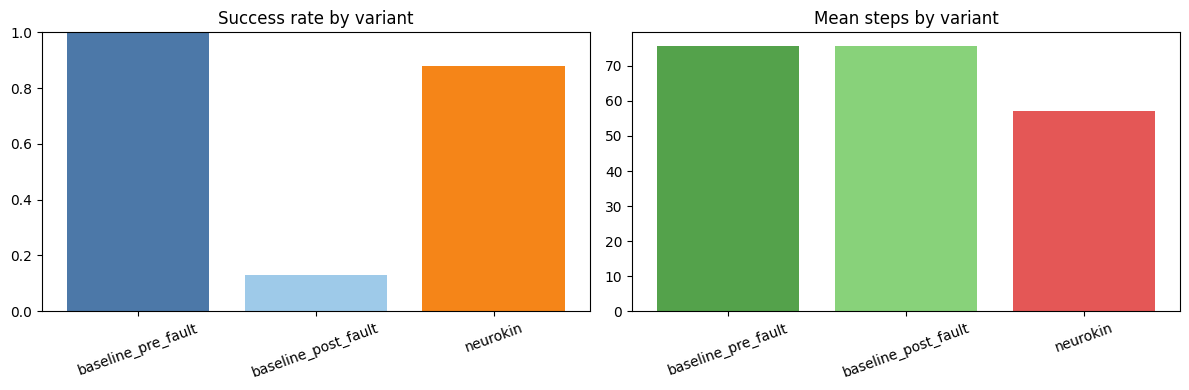

Baseline pre-fault success: 100.0%
Baseline post-fault success: 13.0%
NeuroKin success: 88.0%
Reload verification passed.


In [6]:
def summarize_results(df, label):
    summary = df.groupby("variant").agg(
        success_rate=("success", "mean"),
        mean_steps=("steps", "mean"),
        median_steps=("steps", "median"),
        failures=("success", lambda s: int((~s).sum())),
    ).reset_index()
    summary["label"] = label
    return summary


model = load_model()
fault_config = {
    "num_robots": NUM_ROBOTS,
    "seed": SEED,
    "fault_seed": FAULT_SEED,
    "urdf_path": str(URDF_PATH),
    "model_path": str(MODEL_PATH),
    "device": str(DEVICE),
}
(OUT_DIR / "config.json").write_text(json.dumps(fault_config, indent=2))

logger.info("Running baseline with fault injection...")
logs_bl, success_pre_bl, success_post_bl, time_bl = run_single_robot_chain_faulty_baseline(URDF_PATH, num_stages=NUM_ROBOTS, seed=SEED)
baseline_df = pd.DataFrame([
    {
        "trial": i + 1,
        "variant": "baseline",
        "pre_fault_success": bool(pre),
        "post_fault_success": bool(post),
        "steps": int(log["steps"]),
    }
    for i, (log, pre, post) in enumerate(zip(logs_bl, success_pre_bl, success_post_bl))
])
baseline_df.to_csv(OUT_DIR / "baseline_fault.csv", index=False)

logger.info("Running NeuroKin with fault injection...")
logs_nk, success_nk, time_nk = run_single_robot_chain_faulty_neurokin_v2(URDF_PATH, model, DEVICE, num_stages=NUM_ROBOTS, seed=SEED)
neurokin_df = pd.DataFrame([
    {"trial": i + 1, "variant": "neurokin", "success": bool(ok), "steps": int(log["steps"])}
    for i, (log, ok) in enumerate(zip(logs_nk, success_nk))
])
neurokin_df.to_csv(OUT_DIR / "neurokin_fault.csv", index=False)

baseline_summary = pd.DataFrame([
    {"variant": "baseline_pre_fault", "success_rate": baseline_df["pre_fault_success"].mean(), "mean_steps": baseline_df["steps"].mean(), "median_steps": baseline_df["steps"].median(), "failures": int((~baseline_df["pre_fault_success"]).sum())},
    {"variant": "baseline_post_fault", "success_rate": baseline_df["post_fault_success"].mean(), "mean_steps": baseline_df["steps"].mean(), "median_steps": baseline_df["steps"].median(), "failures": int((~baseline_df["post_fault_success"]).sum())},
])
neurokin_summary = pd.DataFrame([
    {"variant": "neurokin", "success_rate": neurokin_df["success"].mean(), "mean_steps": neurokin_df["steps"].mean(), "median_steps": neurokin_df["steps"].median(), "failures": int((~neurokin_df["success"]).sum())},
])
summary_df = pd.concat([baseline_summary, neurokin_summary], ignore_index=True)
summary_df.to_csv(OUT_DIR / "summary_fault.csv", index=False)
print(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(summary_df["variant"], summary_df["success_rate"], color=["#4c78a8", "#9ecae9", "#f58518"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Success rate by variant")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(summary_df["variant"], summary_df["mean_steps"], color=["#54a24b", "#88d27a", "#e45756"])
axes[1].set_title("Mean steps by variant")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_fault.png", dpi=150)
plt.show()

print(f"Baseline pre-fault success: {baseline_df['pre_fault_success'].mean():.1%}")
print(f"Baseline post-fault success: {baseline_df['post_fault_success'].mean():.1%}")
print(f"NeuroKin success: {neurokin_df['success'].mean():.1%}")

reload_check = pd.read_csv(OUT_DIR / "summary_fault.csv")
assert len(reload_check) == 3
print("Reload verification passed.")

In [7]:
print(f"OUT_DIR: {OUT_DIR.resolve()}")
for path in OUT_DIR.glob("*.csv"):
    print(f"- {path.name}")

print("\nsummary_fault.csv head:")
print(pd.read_csv(OUT_DIR / "summary_fault.csv").head())

print("\nbaseline_fault.csv head:")
print(pd.read_csv(OUT_DIR / "baseline_fault.csv").head())

print("\nneurokin_fault.csv head:")
print(pd.read_csv(OUT_DIR / "neurokin_fault.csv").head())

OUT_DIR: /content/phase2_fault_100_injection
- neurokin_fault.csv
- summary_fault.csv
- baseline_fault.csv

summary_fault.csv head:
               variant  success_rate  mean_steps  median_steps  failures
0   baseline_pre_fault          1.00       75.79          48.5         0
1  baseline_post_fault          0.13       75.79          48.5        87
2             neurokin          0.88       57.04          34.5        12

baseline_fault.csv head:
   trial   variant  pre_fault_success  post_fault_success  steps
0      1  baseline               True               False    169
1      2  baseline               True                True    201
2      3  baseline               True                True    201
3      4  baseline               True                True    201
4      5  baseline               True                True    201

neurokin_fault.csv head:
   trial   variant  success  steps
0      1  neurokin     True     27
1      2  neurokin     True     35
2      3  neurokin     True  

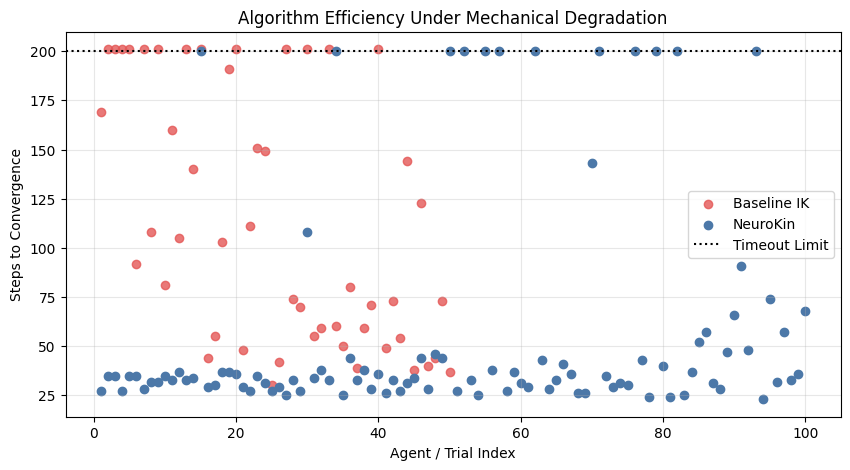

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

baseline_df = pd.read_csv(OUT_DIR / "baseline_fault.csv")
neurokin_df = pd.read_csv(OUT_DIR / "neurokin_fault.csv")

plt.figure(figsize=(10, 5))

# Changed plt.plot to plt.scatter to plot as points
plt.scatter(baseline_df['trial'][:50], baseline_df['steps'][:50], color='#e45756', alpha=0.8, label='Baseline IK')
plt.scatter(neurokin_df['trial'], neurokin_df['steps'], color='#4c78a8', label='NeuroKin')

plt.axhline(y=200, color='black', linestyle=':', label='Timeout Limit')
plt.xlabel('Agent / Trial Index')
plt.ylabel('Steps to Convergence')
plt.title('Algorithm Efficiency Under Mechanical Degradation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "swarm_variance_plot.pdf", format="pdf", bbox_inches="tight")